# Objective:
## Test if offering a ₹20,000 credit limit increase leads to a statistically significant rise in average monthly spend.

### Let μ₁ = mean monthly spend (Group A: No increase),
### μ₂ = mean monthly spend (Group B: ₹20,000 increase)

### Null (H₀): μ₁ = μ₂ (no difference in means)

### Alternative (H₁): μ₁ ≠ μ₂ (limit increase affects spending)

In [2]:
import numpy as np
import pandas as pd
# Load the dataset
df=pd.read_csv('customer_spend_data.csv')
# Preview the dataset
print(df.head())

   customer_id group  monthly_spend
0            1     A   33973.713224
1            2     A   28893.885591
2            3     A   35181.508305
3            4     A   42184.238851
4            5     A   28126.773002


## Exploratory Data Analysis


📌 Summary Statistics by Group
               mean        median          std          min           max
group                                                                    
A      30054.703957  30102.377171  7850.025979  4069.861279  60821.851925
B      33286.435054  33256.784396  8801.974757  8728.020214  56691.438584


C:\Users\jshre\AppData\Local\Temp\ipykernel_22472\3131802997.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='group', y='monthly_spend', palette='Set2')


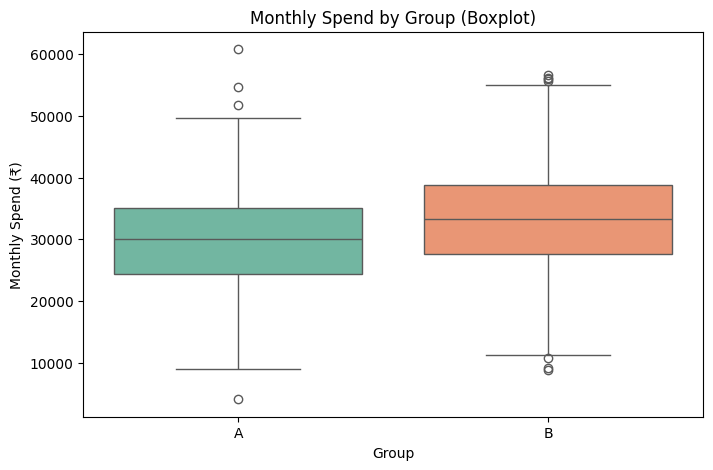

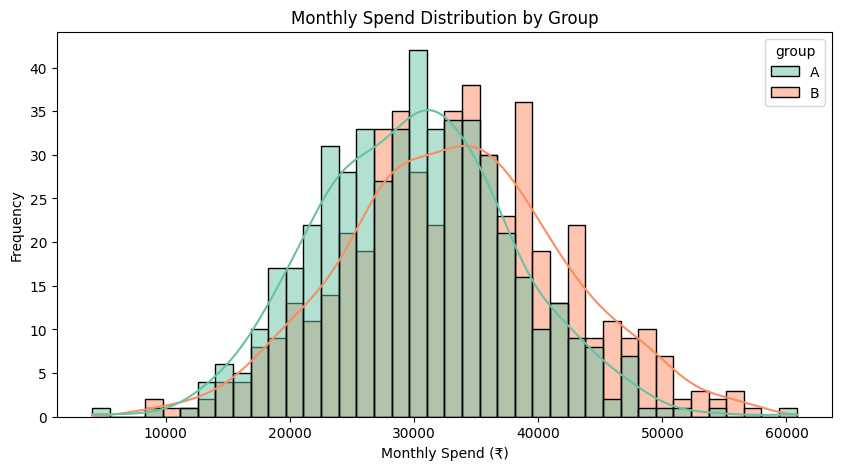


📌 Outlier Count by Group (IQR method)
Group A: 4 outliers
Group B: 7 outliers

📌 Shapiro-Wilk Normality Test
Group A: W = 0.997, p-value = 0.4013 (Normal)
Group B: W = 0.998, p-value = 0.6757 (Normal)


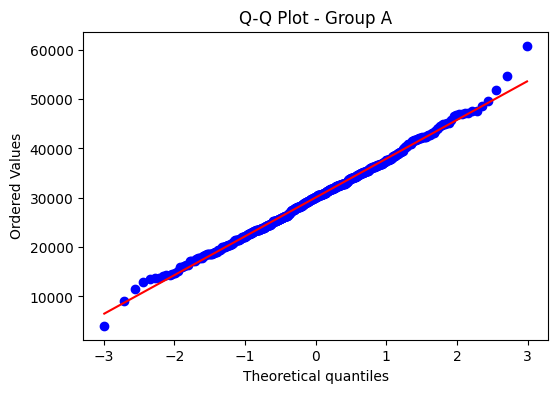

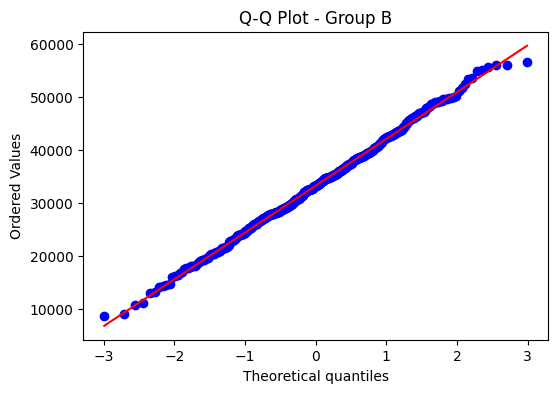

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis, shapiro, normaltest, probplot



# --- Basic Summary Statistics ---
print("\n📌 Summary Statistics by Group")
summary_stats = df.groupby('group')['monthly_spend'].agg(['mean', 'median', 'std', 'min', 'max'])
print(summary_stats)

# --- Boxplots to Compare Groups ---
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='group', y='monthly_spend', palette='Set2')
plt.title('Monthly Spend by Group (Boxplot)')
plt.xlabel('Group')
plt.ylabel('Monthly Spend (₹)')
plt.show()

# --- Histograms & KDEs ---
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='monthly_spend', hue='group', bins=40, kde=True, palette='Set2')
plt.title('Monthly Spend Distribution by Group')
plt.xlabel('Monthly Spend (₹)')
plt.ylabel('Frequency')
plt.show()

# --- Outlier Detection (IQR Method) ---
def detect_outliers_iqr(data):
    Q1 = np.percentile(data, 25)
    Q3 = np.percentile(data, 75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return ((data < lower) | (data > upper)).sum()

print("\n📌 Outlier Count by Group (IQR method)")
for grp in ['A', 'B']:
    outliers = detect_outliers_iqr(df[df['group'] == grp]['monthly_spend'])
    print(f"Group {grp}: {outliers} outliers")


# --- Shapiro-Wilk Test for Normality (Sample ≤ 5000) ---
print("\n📌 Shapiro-Wilk Normality Test")
for grp in ['A', 'B']:
    data = df[df['group'] == grp]['monthly_spend']
    stat, p = shapiro(data)
    print(f"Group {grp}: W = {stat:.3f}, p-value = {p:.4f} {'(Normal)' if p > 0.05 else '(Not Normal)'}")


# --- Q-Q Plots ---
for grp in ['A', 'B']:
    data = df[df['group'] == grp]['monthly_spend']
    plt.figure(figsize=(6, 4))
    probplot(data, dist="norm", plot=plt)
    plt.title(f'Q-Q Plot - Group {grp}')
    plt.show()


## Power Analysis (A Priori)

In [4]:
from statsmodels.stats.power import TTestIndPower
import matplotlib.pyplot as plt
import numpy as np

# Initialize power analysis object
analysis = TTestIndPower()

# Define analysis parameters
alpha = 0.05         # significance level
power = 0.8          # desired power
effect_sizes = [0.2, 0.3, 0.5, 0.8]  # common Cohen's d values

# 📌 Print required sample size per group for selected effect sizes
print("📌 Required Sample Size per Group (Two-sample t-test):")
for es in effect_sizes:
    n = analysis.solve_power(effect_size=es, power=power, alpha=alpha, alternative='two-sided')
    print(f"Effect Size = {es}: Sample Size ≈ {int(np.ceil(n))} per group")





📌 Required Sample Size per Group (Two-sample t-test):
Effect Size = 0.2: Sample Size ≈ 394 per group
Effect Size = 0.3: Sample Size ≈ 176 per group
Effect Size = 0.5: Sample Size ≈ 64 per group
Effect Size = 0.8: Sample Size ≈ 26 per group


## Levene's test

In [7]:
# Optional: Use Levene's test to verify equal variances
from scipy import stats
group_A = df[df['group'] == 'A']['monthly_spend']
group_B = df[df['group'] == 'B']['monthly_spend']
levene_stat, levene_p = stats.levene(group_A, group_B)
equal_var = True if levene_p > 0.05 else False
print(f"\n📌 Levene’s test for equal variances: p = {levene_p:.4f} → {'Equal variances' if equal_var else 'Unequal variances'}")


📌 Levene’s test for equal variances: p = 0.0146 → Unequal variances


## Welch's t Test

In [8]:
from scipy.stats import ttest_ind

# Subset data for each group
group_A = df[df['group'] == 'A']['monthly_spend']
group_B = df[df['group'] == 'B']['monthly_spend']

# Welch's t-test (equal_var=False)
t_stat, p_value = ttest_ind(group_A, group_B, equal_var=False)

print("📊 Welch’s T-Test Results")
print(f"T-statistic: {t_stat:.3f}")
print(f"P-value: {p_value:.4f}")

# Interpretation
if p_value < 0.05:
    print("✅ Reject Null Hypothesis: The mean monthly spend is significantly different between groups.")
else:
    print("❌ Fail to Reject Null: No significant difference in mean monthly spend.")


📊 Welch’s T-Test Results
T-statistic: -6.127
P-value: 0.0000
✅ Reject Null Hypothesis: The mean monthly spend is significantly different between groups.


## Effect Size (Cohen's d)

In [9]:
import numpy as np

# Subset the data
group_A = df[df['group'] == 'A']['monthly_spend']
group_B = df[df['group'] == 'B']['monthly_spend']

# Means and standard deviations
mean_A = np.mean(group_A)
mean_B = np.mean(group_B)
std_A = np.std(group_A, ddof=1)
std_B = np.std(group_B, ddof=1)

# Pooled standard deviation
n_A = len(group_A)
n_B = len(group_B)
pooled_std = np.sqrt(((n_A - 1) * std_A**2 + (n_B - 1) * std_B**2) / (n_A + n_B - 2))

# Cohen's d
cohen_d = (mean_B - mean_A) / pooled_std

print("📐 Effect Size: Cohen’s d")
print(f"Mean A (No Increase): ₹{mean_A:.2f}")
print(f"Mean B (Limit Increase): ₹{mean_B:.2f}")
print(f"Cohen’s d: {cohen_d:.3f}")

# Optional: Interpret Cohen's d
if abs(cohen_d) < 0.2:
    interpretation = "negligible"
elif abs(cohen_d) < 0.5:
    interpretation = "small"
elif abs(cohen_d) < 0.8:
    interpretation = "medium"
else:
    interpretation = "large"

print(f"Interpretation: {interpretation.capitalize()} effect size")


📐 Effect Size: Cohen’s d
Mean A (No Increase): ₹30054.70
Mean B (Limit Increase): ₹33286.44
Cohen’s d: 0.388
Interpretation: Small effect size


## Confidence Interval 

In [10]:
import numpy as np
from scipy import stats

# Subset groups
group_A = df[df['group'] == 'A']['monthly_spend']
group_B = df[df['group'] == 'B']['monthly_spend']

# Sample sizes
n1 = len(group_A)
n2 = len(group_B)

# Means
mean1 = np.mean(group_A)
mean2 = np.mean(group_B)

# Standard deviations
std1 = np.std(group_A, ddof=1)
std2 = np.std(group_B, ddof=1)

# Difference in means
mean_diff = mean2 - mean1

# Standard error for Welch's t-test (unequal variances)
se_diff = np.sqrt((std1**2 / n1) + (std2**2 / n2))

# Degrees of freedom (Welch–Satterthwaite equation)
df_denom = ((std1**2 / n1)**2 / (n1 - 1)) + ((std2**2 / n2)**2 / (n2 - 1))
df = (std1**2 / n1 + std2**2 / n2)**2 / df_denom

# 95% Confidence interval
confidence = 0.95
alpha = 1 - confidence
t_critical = stats.t.ppf(1 - alpha/2, df)

ci_lower = mean_diff - t_critical * se_diff
ci_upper = mean_diff + t_critical * se_diff

# Print results
print("📊 95% Confidence Interval for Mean Difference (Welch’s t-test)")
print(f"Mean Spend A: ₹{mean1:.2f}")
print(f"Mean Spend B: ₹{mean2:.2f}")
print(f"Difference in Means (B - A): ₹{mean_diff:.2f}")
print(f"95% CI: ₹({ci_lower:.2f}, {ci_upper:.2f})")


📊 95% Confidence Interval for Mean Difference (Welch’s t-test)
Mean Spend A: ₹30054.70
Mean Spend B: ₹33286.44
Difference in Means (B - A): ₹3231.73
95% CI: ₹(2196.69, 4266.77)
